#Class

## 1. Loading data

In [47]:
!pip install nltk

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import os

file_path = '/content/drive/MyDrive/CPE393/books.txt'
print(os.path.exists(file_path))

True


In [50]:
import nltk
# nltk.download('all')
# nltk.download() #for the missing library
nltk.download('punkt_tab')
dir = '/content/drive/MyDrive/CPE393/'
f = open(dir+'books.txt', encoding='utf-8')
raw = f.read()
tokens = nltk.word_tokenize(raw)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [51]:
print(tokens[1000:1100])

[',', 'eating', 'banquets', 'in', 'the', 'Great', 'Hall', ',', 'sleep\xading', 'in', 'his', 'four-poster', 'bed', 'in', 'the', 'tower', 'dormitory', ',', 'visiting', 'the', 'gamekeeper', ',', 'Hagrid', ',', 'in', 'his', 'cabin', 'next', 'to', 'the', 'Forbidden', 'Forest', 'in', 'the', 'grounds', ',', 'and', ',', 'especially', ',', 'Quidditch', ',', 'the', 'most', 'popular', 'sport', 'in', 'the', 'wizarding', 'world', '(', 'six', 'tall', 'goal', 'posts', ',', 'four', 'flying', 'balls', ',', 'and', 'four\xadteen', 'players', 'on', 'broomsticks', ')', '.', 'All', 'Harry', '’', 's', 'spellbooks', ',', 'his', 'wand', ',', 'robes', ',', 'cauldron', ',', 'and', 'top-of-the-line', 'Nimbus', 'Two', 'Thousand', 'broomstick', 'had', 'been', 'locked', 'in', 'a', 'cupboard', 'under', 'the', 'stairs', 'by', 'Uncle', 'Vernon', 'the', 'instant']


## 2. Regular expression

In [52]:
tokens = [w.lower() for w in tokens]

In [53]:
import re

[w for w in tokens if re.search('ed$', w)][:10]

['reserved',
 'published',
 'registered',
 'related',
 'reproduced',
 'stored',
 'transmitted',
 'opened',
 'released',
 'printed']

---
**1. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **ed$ หมายถึง ค้นหาคำที่ลงท้ายด้วยตัวอักษร "ed"**<br>
ดังนั้นคำที่แสดงออกมาจะเป็นคำที่ลงท้ายด้วย "ed" เช่น reserved, published<br>
ในทางกลับกันคำที่ไม่ตรงกับรูปแบบนี้ก็คือคำที่ไม่ได้ลงท้ายด้วย "ed" เช่น <br>
- education (มี ed อยู่ข้างหน้า ไม่ใช่ท้ายคำ)<br>
- fast (ไม่ลงท้ายด้วย ed)
---

In [54]:
[w for w in tokens if re.search('^..j..t..$', w)]

['dejected',
 'adjusted',
 'rejected',
 'rejected',
 'dejected',
 'adjusted',
 'adjusted',
 'adjusted',
 'adjusted']

---
**2. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **^..j..t..$ หมายถึง ค้นหาคำที่มี 8 ตัว ซึ่งตัวที่ 3 เป็น "j" และตัวที่ 6  เป็น "t" ส่วนตัวที่เลือกเป็นอะไรก็ได้** <br>
ดังนั้นคำที่แสดงออกมาจะเป็นคำที่มี 8 ตัว ซึ่งตัวที่ 3 เป็น "j" และตัวที่ 6  เป็น "t" ส่วนตัวที่เลือกเป็นอะไรก็ได้เช่น dejected, adjusted<br>
ในทางกลับกันคำที่ไม่ตรงกับรูปแบบนี้ก็คือคำที่มีตัวอักษรไม่เท่ากับ 8 ตัวหรือตัวที่ 3 ไม่เป็น "j" และตัวที่ 6 ไม่เป็น "t" <br>
- reject (ความยาวแค่ 6 ตัว) <br>
- projected (ความยาวเกิน 8 ตัว) <br>
- objected (ตำแหน่งที่ 3 ไม่ใช่ j)
---

In [55]:
[w for w in tokens if re.search('^spo.ts?$', w)][:10]

['sport',
 'sports',
 'sport',
 'sport',
 'sports',
 'sport',
 'sports',
 'sports',
 'sports',
 'sports']

---
**3. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **^spo.ts?$ หมายถึง ค้นหาคำที่ขึ้นต้นด้วย "spo" ตามด้วยตัวอักษรใด ๆ หนึ่งตัว และตามด้วย "t" จากนั้นอาจจะมี "s" 1 ตัวหรือไม่มีเลยก็ได้** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้จะเป็นคำที่มีความยาว 5 หรือ 6 ตัวอักษร เช่น sport, spots <br>
ในทางกลับกัน คำที่ไม่ตรงคือคำที่ไม่ได้ขึ้นต้นด้วย "spo" หรือไม่มี "t" เป็นตัวรองสุดท้าย เช่น <br>
- spoon (ไม่มีตัว t) <br>
- spore (ไม่มีตัว t) <br>
- sporting (เกิน 6 ตัวอักษร)
---

In [56]:
[w for w in tokens if re.search('^[b-f]', w)][:10]

['chamber',
 'by',
 'by',
 'books',
 'for',
 'f.',
 'driver',
 'foul-weather',
 'friend',
 'copyright']

---
**4. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **^[b-f] หมายถึง ค้นหาคำที่ขึ้นต้นด้วยตัวอักษรใดก็ได้ระหว่าง b ถึง f (รวม b, c, d, e, f)** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำที่อักษรตัวแรกอยู่ในช่วง b–f เช่น banana, cat, dog, elephant, fish <br>
ในทางกลับกันคำที่ไม่ตรงคือคำที่ไม่ได้ขึ้นต้นด้วย b–f เช่น <br>
- apple (ขึ้นต้นด้วย a) <br>
- grape (ขึ้นต้นด้วย g) <br>
- zebra (ขึ้นต้นด้วย z)
---


In [57]:
[w for w in tokens if re.search('^[bdf][aue][rts]$', w)][:10]

['but', 'but', 'far', 'but', 'but', 'but', 'fat', 'but', 'fat', 'but']

---
**5. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **^[bdf][aue][rts]$ หมายถึง ค้นหาคำที่มีความยาว 3 ตัวอักษร โดยตัวแรกต้องเป็น b, d หรือ f ตัวที่สองต้องเป็น a, u หรือ e และตัวที่สามต้องเป็น r, t หรือ s** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำที่มี 3 ตัวอักษร และตรงตามเงื่อนไขแต่ละตัว เช่น but, bet, fur, dus <br>
ในทางกลับกันคำที่ไม่ตรงคือคำที่ไม่ใช่ 3 ตัวอักษร หรือไม่ตรงตามเงื่อนไขตัวอักษรแต่ละตำแหน่ง เช่น <br>
- cat (ตัวแรกไม่ใช่ b, d, f) <br>
- fun (ตัวสามไม่ใช่ r, t, s) <br>
- dusted (ความยาวเกิน 3 ตัว)
---

In [58]:
set([w for w in tokens if re.search('noo+$', w)])

{'nooo',
 'noooo',
 'nooooo',
 'noooooo',
 'nooooooo',
 'nooooooooo',
 'noooooooooooo',
 'nooooooooooooooooo'}

---
**6. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **noo+$ หมายถึง ค้นหาคำที่ลงท้ายด้วยตัวอักษร "no" ตามด้วย "o" ซ้ำอย่างน้อยหนึ่งตัว** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำที่ลงท้ายด้วย "no" + "o" ซ้ำ เช่น nooo, nooooo, technoo <br>
ในทางกลับกันคำที่ไม่ตรงคือคำที่ไม่ลงท้ายด้วย "no" + "o" ซ้ำ เช่น <br>
- no (ไม่ลงท้ายด้วย "no" + "o"อย่างน้อยหนึ่งตัว) <br>
- noon (ไม่ลงท้ายด้วย "no" + "o"อย่างน้อยหนึ่งตัว) <br>
- banana (ไม่ลงท้ายด้วย "no" + "o"อย่างน้อยหนึ่งตัว)
---

In [59]:
set([w for w in tokens if re.search('noo*$', w)])

{'albino',
 'dunno',
 'gemino',
 'inferno',
 'n-no',
 'no',
 'nooo',
 'noooo',
 'nooooo',
 'noooooo',
 'nooooooo',
 'nooooooooo',
 'noooooooooooo',
 'nooooooooooooooooo',
 'oppugno',
 'palomino',
 'patrono',
 'piano',
 'pi\xadano',
 'rhino',
 'xeno'}

---
**7. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **noo*$ หมายถึง ค้นหาคำที่ลงท้ายด้วยตัวอักษร "no" แล้วตามด้วย "o" ตั้งแต่ 0 ตัวขึ้นไป** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำที่ลงท้ายด้วย "no" แล้วตามด้วย "o" ตั้งแต่ 0 ตัวขึ้นไป เช่น no, noo, nooo, techno <br>
ในทางกลับกันคำที่ไม่ตรงคือคำที่ไม่ลงท้ายด้วย "no" แล้วตามด้วย "o" ตั้งแต่ 0 ตัวขึ้นไป เช่น <br>
- na (ไม่ลงท้ายด้วย "no" แล้วตามด้วย "o" ตั้งแต่ 0 ตัวขึ้นไป ) <br>
- banana (ไม่ลงท้ายด้วย "no" แล้วตามด้วย "o" ตั้งแต่ 0 ตัวขึ้นไป ) <br>
- note (ไม่ลงท้ายด้วย "no" แล้วตามด้วย "o" ตั้งแต่ 0 ตัวขึ้นไป )
---


In [60]:
[w for w in tokens if re.search('\.+$', w)][:10]

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-707925584.py:1: SyntaxWarning: invalid escape sequence '\.'
  [w for w in tokens if re.search('\.+$', w)][:10]


['j.', 'k.', 'a.', 'p.', 'f.', '.', 'j.', 'k.', '.', 'bros.']

---
**8. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **\.+$ หมายถึง ค้นหาคำหรือสตริงที่ลงท้ายด้วยจุด (.) อย่างน้อย 1 ตัว** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำหรือสตริงที่ลงท้ายด้วย "." เช่น ., end., hello..., version. <br>
ในทางกลับกันคำที่ไม่ตรงคือคำหรือสตริงที่ไม่ลงท้ายด้วย "." เช่น <br>
- .hello (ไม่มีจุดลงท้าย) <br>
- world (ไม่มีจุดลงท้าย) <br>
- test (ไม่มีจุดลงท้าย)
---

In [61]:
[w for w in tokens if re.search('^[A-Z]+\.$', w)]

<>:1: SyntaxWarning: invalid escape sequence '\.'
<>:1: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1844296225.py:1: SyntaxWarning: invalid escape sequence '\.'
  [w for w in tokens if re.search('^[A-Z]+\.$', w)]


[]

---
**9. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **^[A-Z]+\.$ หมายถึง ค้นหาคำที่ประกอบด้วยตัวอักษรพิมพ์ใหญ่ (A–Z) อย่างน้อยหนึ่งตัว และลงท้ายด้วยจุด (.)** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำที่เป็นตัวพิมพ์ใหญ่ทั้งหมดและลงท้ายด้วย "." เช่น HELLO., WORLD., TEST. <br>
ในทางกลับกันคำที่ไม่ตรงคือคำหรือสตริงที่ไม่ใช่ตัวพิมพ์ใหญ่ทั้งหมด หรือไม่ลงท้ายด้วย "." เช่น <br>
- Hello. (มีตัวพิมพ์เล็ก) <br>
- WORLD (ไม่มีจุดลงท้าย) <br>
- test. (เป็นตัวพิมพ์เล็ก)
---


In [62]:
[w for w in tokens if re.search('^[0-9]{4}$', w)][:10]

['1999',
 '1999',
 '1920',
 '1999',
 '1999',
 '1875',
 '1492',
 '1289',
 '2007',
 '2007']

---
**10. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **^[0-9]{4}$ หมายถึง ค้นหาคำที่ประกอบด้วยตัวเลข 0–9 จำนวน 4 ตัว** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือตัวเลข 4 ตัว เช่น 2025, 1234, 0001 <br>
ในทางกลับกันคำที่ไม่ตรงคือสตริงที่ไม่ใช่ตัวเลข 4 ตัว เช่น <br>
- 123 (มีแค่ 3 ตัว) <br>
- 12345 (มี 5 ตัว) <br>
- ab12 (มีตัวอักษร)
---


In [63]:
set([w for w in tokens if re.search('(ed|ing)$', w)][:10])

{'published',
 'publishing',
 'registered',
 'related',
 'reproduced',
 'reserved',
 'rowling',
 'stored'}

---
**11. What kind of input that matches, and what do not? Also, give a brief explanation.**

Ans: **(ed|ing)$ หมายถึง ค้นหาคำที่ลงท้ายด้วย "ed" หรือ "ing"** <br>
ดังนั้นคำที่ตรงกับรูปแบบนี้คือคำที่ลงท้ายด้วย "ed" หรือ "ing" เช่น walked, jumping, played, running <br>
ในทางกลับกันคำที่ไม่ตรงคือคำที่ไม่ลงท้ายด้วย "ed" หรือ "ing" เช่น <br>
- walk (ไม่มี "ed" หรือ "ing") <br>
- run (ไม่มี "ed" หรือ "ing") <br>
- play (ไม่มี "ed" หรือ "ing")
---


## 3. Regular expression tokenizer

###3.1 Basic regex tokenizer

In [64]:
s = ("Good muffins cost $3.88\nin New York.  Please buy me\n"
      "two of them.\n\nThanks.")
s2 = ("Alas, it has not rained today. When, do you think, "
      "will it rain again?")
s3 = ("<p>Although this is <b>not</b> the case here, we must "
      "not relax our vigilance!</p>")

In [65]:
s2

'Alas, it has not rained today. When, do you think, will it rain again?'

In [66]:
nltk.regexp_tokenize(s2, r'[,\.\?!"]\s*', gaps=True)

['Alas',
 'it has not rained today',
 'When',
 'do you think',
 'will it rain again']

---
**12.What happened after applying the above RegEx tokenizer to the input string?**

Ans: **แยกคำโดยใช้เครื่องหมาย , . ? ! " เป็นตัวแบ่งคำ**

---

In [67]:
s3

'<p>Although this is <b>not</b> the case here, we must not relax our vigilance!</p>'

In [68]:
nltk.regexp_tokenize(s3, r'</?.>', gaps=False)

['<p>', '<b>', '</b>', '</p>']

---
**13.What happened after applying the above RegEx tokenizer to the input string?**

Ans: **ค้นหาคำที่มีเครื่องหมาย < >ประกบ เช่น <b>, </b>**

---

In [69]:
nltk.regexp_tokenize(s3, r'</?.>', gaps=True)

['Although this is ',
 'not',
 ' the case here, we must not relax our vigilance!']

---
**14.What happened after applying the above RegEx tokenizer to the input string?**

Ans: **แยกคำโดยใช้เครื่องหมาย < > เป็นตัวแบ่งคำ****

---

In [70]:
tokens[:10]

['harry', 'potter', 'and', 'the', 'chamber', 'of', 'secrets', 'by', 'j.', 'k.']

# Harry Potter series

## Cleaning text

In [71]:
# 1. Lowercase all tokens
tokens = [w.lower() for w in tokens]

In [72]:
# 2. Show punctuation and non-alphanumeric characters
from collections import Counter
punctuation_chars = []

# find
for w in tokens:
    punctuation_chars.extend(re.findall(r'[^a-zA-Z0-9]', w))

# counter
punctuation_count = Counter(punctuation_chars)

# result
for char, count in punctuation_count.items():
    print(f"{char} : {count}")


. : 65759
é : 30
á : 1
- : 5660
© : 23
, : 86310
/ : 10
: : 1474
[ : 6
— : 9711
] : 6
’ : 34979
“ : 37060
! : 7637
” : 36750
? : 10865
­ : 9622
… : 7957
; : 3482
‘ : 511
( : 329
) : 331
* : 57
' : 3
& : 2
ˮ : 1
ß : 1
¬ : 1
– : 9
ù : 1


In [73]:
# 3. Remove punctuation and non-alphanumeric characters from each token
tokens = [re.sub(r'[^a-zA-Z0-9]', '', w) for w in tokens]

In [74]:
# 4. Show space or empty tokens
empty_count = sum(w.strip() == '' for w in tokens)
print(f"Empty or space-only tokens count: {empty_count}")

Empty or space-only tokens count: 294308


In [94]:
# 5. Remove space or empty tokens
tokens = [w for w in tokens if re.sub(r'\s+', '', w) != '']

In [76]:
# 6. Show single characters b-z
single_chars = []

# find
for w in tokens:
    single_chars.extend(re.findall(r'^[a-z]{1}$', w))

# counter
single_count = Counter(single_chars)

# result
for char, count in sorted(single_count.items()):
    print(f"'{char}' : {count}")

'a' : 21038
'b' : 13
'c' : 61
'd' : 1984
'e' : 52
'f' : 5
'g' : 5
'h' : 9
'i' : 13557
'j' : 22
'k' : 19
'l' : 4
'm' : 1358
'n' : 25
'o' : 258
'p' : 15
'r' : 7
's' : 14750
't' : 7703
'u' : 1
'v' : 1
'w' : 6
'x' : 2
'y' : 20
'z' : 1


In [77]:
# 7. Remove single characters b-z
tokens = [re.sub(r'\b[b-z]\b', '', w) for w in tokens]

In [95]:
print("Clean tokens:", tokens[:10])

Clean tokens: ['harry', 'potter', 'and', 'the', 'chamber', 'of', 'secrets', 'by', 'rowling', 'illustrations']


## EDA

จำนวนบทของหนังสือ

In [79]:
cleaned_text = ' '.join(tokens)  # รวม tokens เป็น string

# ใช้ regex chapter [\d][\d]* → chapter ตามด้วยตัวเลข 1 หลักขึ้นไป
chapter_matches = re.findall(r'chapter [\d][\d]*', cleaned_text)

# นับจำนวน occurrence
chapter_count = len(chapter_matches)

print(f"The phrase 'chapter xx' appears {chapter_count} times in the text.")

The phrase 'chapter xx' appears 199 times in the text.


จำนวนเล่มของหนังสือ

In [80]:
# ใช้ regex หา "chapter 1"
chapter_1_matches = re.findall(r'\bchapter 1\b', cleaned_text)

# นับจำนวน occurrence
chapter_1_count = len(chapter_1_matches)

print(f"The phrase 'chapter 1' appears {chapter_1_count} times in the text.")

The phrase 'chapter 1' appears 7 times in the text.


In [91]:
# def extract_chapters(book):
#     chapters_in_book = re.findall(r'chapter \d+\b', book, flags=re.IGNORECASE)

#     start = 0
#     while(start != len(chapters_in_book)):
#         chap_id = "chapter {}"
#         start_index = cleaned_text.index(chap_id.format(start+1))
#         print(cleaned_text[start_index:start_index+100])

#         start += 1


# book_sections = re.split(r'(?i)(?=chapter 1\b)', cleaned_text)
# books = [section.strip() for section in book_sections if section.strip() != '']

# for i, book in enumerate(books[1:]): # books[0] is just preface so, skipped!
#     print(f'''=============
# Book {i+1} content''')
#     extract_chapters(book)
#     print("\n")

พิจารณา book_2 เนื่องจากจำนวนบทไม่ตรง เพราะ chapter 18 อ้างอิง chapter 22 ในเนื้อหา

*หมายเหตุ ! <br>ตอนแรกคิดว่าจะรวม chapter 18 กับ chapter 19 แล้วลบ chapter 19 ออกเหมือนใน comment*

In [82]:
book_index = 2  # enumerate start from 0
book_2 = books[book_index]

# split chapters
chapters_in_book2 = re.split(r'(?i)(?=chapter \d+\b)', book_2)
chapters_in_book2 = [ch.strip() for ch in chapters_in_book2 if ch.strip()]

# merge chapter 18 and 19, then drop chapter 19
# if len(chapters_in_book2) >= 19:
#     chapters_in_book2[17] = chapters_in_book2[17] + "\n\n" + chapters_in_book2[18]
#     del chapters_in_book2[18]  # remove chapter 19

# results
for j, chapter in enumerate(chapters_in_book2, 1):
    print(f"chapter {j}: {chapter[:100]}...")  # preview first 100 char

chapter 1: chapter 1 the dark lord ascending the two men appeared out of nowhere a few yards apart in the narro...
chapter 2: chapter 2 in memoriam harry was bleeding clutching his right hand in his left and swearing under his...
chapter 3: chapter 3 the dursleys departing the sound of the front door slamming echoed up the stairs and a voi...
chapter 4: chapter 4 the seven potters harry ran back upstairs to his bedroom arriving at the window just in ti...
chapter 5: chapter 5 fallen warrior hagrid harry struggled to raise himself out of the debris of metal and leat...
chapter 6: chapter 6 the ghoul in pajamas the shock of losing madeye hung over the house in the days that follo...
chapter 7: chapter 7 the will of albus dumbledore he was walking along a mountain road in the cool blue light o...
chapter 8: chapter 8 the wedding three  clock on the following afternoon found harry ron fred and george standi...
chapter 9: chapter 9 a place to hide everything seemed fuzzy slow harry and herm

*แต่คิดวิธีที่ดีกว่าได้คือการแบ่ง chapter แบบไล่ลำดับ :)*

##Comparable length each book and all book


In [83]:
# เก็บข้อมูล chapter ที่สั้นที่สุดและยาวที่สุดของทุกเล่ม
shortest_chapter_overall = {"book": None, "chapter": None, "words": float('inf')}
longest_chapter_overall = {"book": None, "chapter": None, "words": 0}

for i, book in enumerate(books, 0):
    # สร้าง pattern ไล่ลำดับ
    chapters = []
    current_pos = 0
    chapter_num = 1

    while True:
        next_chapter_pattern = f'chapter {chapter_num}'
        match = re.search(next_chapter_pattern, book[current_pos:], re.IGNORECASE)
        if not match:
            remaining_text = book[current_pos:].strip()
            if remaining_text:
                chapters.append(remaining_text)
            break
        start = current_pos + match.start()

        if chapter_num > 1:
            chapters.append(book[current_pos:start].strip())

        current_pos = start
        chapter_num += 1

    if i > 0:
        print(f"book_{i} has {len(chapters)} chapters")

        chapter_lengths = [len(ch.split()) for ch in chapters]

        for j, length in enumerate(chapter_lengths, 1):
            print(f"  chapter {j} has {length} words")
            # update the shortest chapter
            if length < shortest_chapter_overall["words"]:
                shortest_chapter_overall = {"book": i, "chapter": j, "words": length}
            # update the longest chapter
            if length > longest_chapter_overall["words"]:
                longest_chapter_overall = {"book": i, "chapter": j, "words": length}

        # Check chapter is the shortest and which is the longest each books
        min_length = min(chapter_lengths)
        max_length = max(chapter_lengths)
        min_index = chapter_lengths.index(min_length) + 1
        max_index = chapter_lengths.index(max_length) + 1

        if min_length != max_length:
            print(f"  -> Shortest chapter in this book: chapter {min_index} ({min_length} words)")
            print(f"  -> Longest chapter in this book: chapter {max_index} ({max_length} words)")

        print()

# Check chapter is the shortest and which is the longest all books
print(f"Overall shortest chapter: book_{shortest_chapter_overall['book']}, "
      f"chapter {shortest_chapter_overall['chapter']} "
      f"({shortest_chapter_overall['words']} words)")

print(f"Overall longest chapter: book_{longest_chapter_overall['book']}, "
      f"chapter {longest_chapter_overall['chapter']} "
      f"({longest_chapter_overall['words']} words)")

book_1 has 18 chapters
  chapter 1 has 2560 words
  chapter 2 has 2843 words
  chapter 3 has 4487 words
  chapter 4 has 5733 words
  chapter 5 has 5395 words
  chapter 6 has 4521 words
  chapter 7 has 4529 words
  chapter 8 has 4360 words
  chapter 9 has 5085 words
  chapter 10 has 5282 words
  chapter 11 has 5937 words
  chapter 12 has 5392 words
  chapter 13 has 5441 words
  chapter 14 has 3911 words
  chapter 15 has 4634 words
  chapter 16 has 5626 words
  chapter 17 has 5341 words
  chapter 18 has 4131 words
  -> Shortest chapter in this book: chapter 1 (2560 words)
  -> Longest chapter in this book: chapter 11 (5937 words)

book_2 has 36 chapters
  chapter 1 has 3083 words
  chapter 2 has 4038 words
  chapter 3 has 3291 words
  chapter 4 has 5349 words
  chapter 5 has 5813 words
  chapter 6 has 6535 words
  chapter 7 has 6498 words
  chapter 8 has 6134 words
  chapter 9 has 4104 words
  chapter 10 has 6594 words
  chapter 11 has 5517 words
  chapter 12 has 6053 words
  chapter 13 

## Find the characters


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

In [84]:
characters = ['harry', 'ron', 'hermione', 'dobby', 'malfoy', 'voldemort|you know who', 'snape', 'dumbledore', 'hagrid', 'sirius']

============= Book 1 =============
HARRY occurrences: 1659
RON occurrences: 845
HERMIONE occurrences: 321
DOBBY occurrences: 153
MALFOY occurrences: 224
VOLDEMORT|YOU KNOW WHO occurrences: 26
SNAPE occurrences: 98
DUMBLEDORE occurrences: 159
HAGRID occurrences: 164
SIRIUS occurrences: 0


============= Book 2 =============
HARRY occurrences: 3154
RON occurrences: 1494
HERMIONE occurrences: 1226
DOBBY occurrences: 46
MALFOY occurrences: 90
VOLDEMORT|YOU KNOW WHO occurrences: 449
SNAPE occurrences: 294
DUMBLEDORE occurrences: 596
HAGRID occurrences: 172
SIRIUS occurrences: 70


============= Book 3 =============
HARRY occurrences: 3175
RON occurrences: 1358
HERMIONE occurrences: 872
DOBBY occurrences: 171
MALFOY occurrences: 140
VOLDEMORT|YOU KNOW WHO occurrences: 241
SNAPE occurrences: 256
DUMBLEDORE occurrences: 601
HAGRID occurrences: 380
SIRIUS occurrences: 223


============= Book 4 =============
HARRY occurrences: 2787
RON occurrences: 1166
HERMIONE occurrences: 695
DOBBY occurrenc

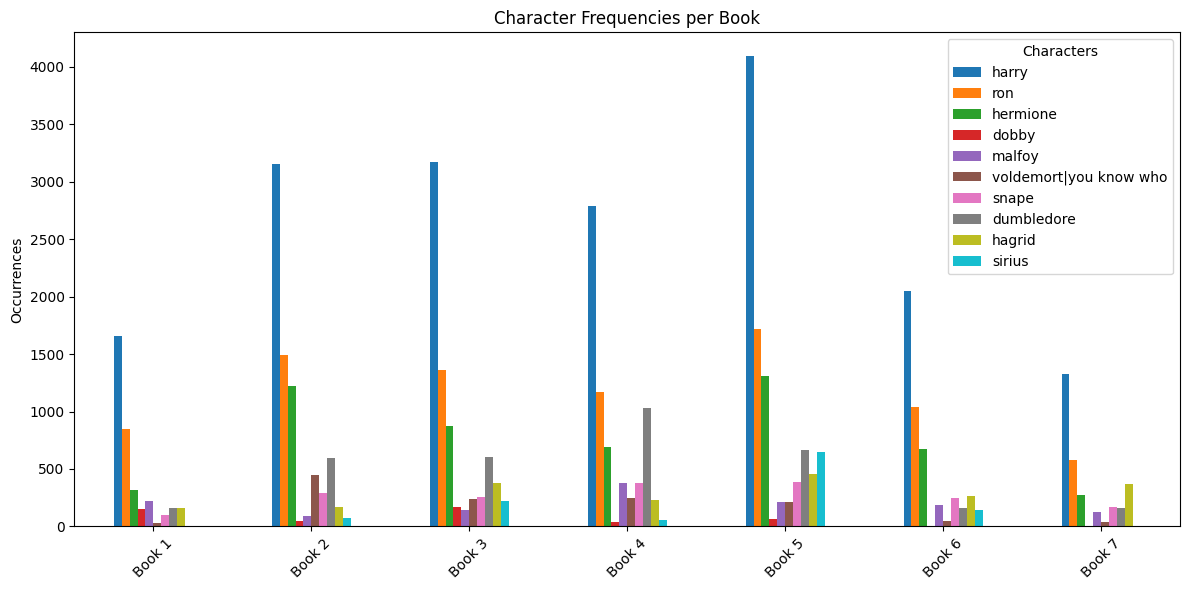

============= Total =============
HARRY occurrences is 18254 times.
RON occurrences is 8200 times.
HERMIONE occurrences is 5365 times.
DOBBY occurrences is 470 times.
MALFOY occurrences is 1363 times.
VOLDEMORT|YOU KNOW WHO occurrences is 1266 times.
SNAPE occurrences is 1829 times.
DUMBLEDORE occurrences is 3375 times.
HAGRID occurrences is 2044 times.
SIRIUS occurrences is 1137 times.


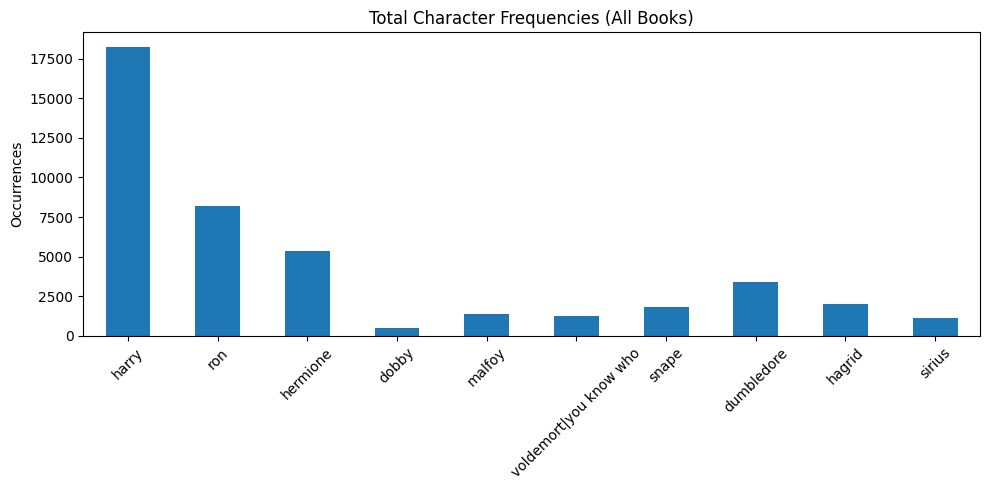

In [90]:
all_books_counts = []

# show the characters each books
for i, book in enumerate(books[1:], 1):
    print(f"============= Book {i} =============")
    book_counts = {}

    for name in characters:
        matches = re.findall(name, book, re.IGNORECASE)
        book_counts[name] = len(matches)
        print(f"{name.upper()} occurrences: {len(matches)}")

    all_books_counts.append(book_counts)
    print("\n")
df = pd.DataFrame(all_books_counts, index=[f"Book {i}" for i in range(1, len(all_books_counts)+1)])

# the character frequencies graph each books
df.plot(kind="bar", figsize=(12,6))
plt.title("Character Frequencies per Book")
plt.ylabel("Occurrences")
plt.xticks(rotation=45)
plt.legend(title="Characters")
plt.tight_layout()
plt.show()

# show the characters all books
print("============= Total =============")
for name in characters:
    matches = re.findall(name, cleaned_text, re.IGNORECASE)  # ใช้ cleaned_text รวมทุกเล่ม
    print(f"{name.upper()} occurrences is {len(matches)} times.")

# the character frequencies graph all books
df_sum = df.sum(axis=0)
df_sum.plot(kind="bar", figsize=(10,5))
plt.title("Total Character Frequencies (All Books)")
plt.ylabel("Occurrences")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
**14. Find out if Harry dominates every chapter, or are there shifts?**

Ans: **Harry เป็นตัวละครที่มีความถี่ในการใช้สูงที่สุดในทุกเล่ม และรองลงมาเป็น Ron ในทุกเล่มเช่นกัน**

---


*Punchaya Chancharoen<br>
65070507236*

